## Explore suitable Sig_R

In [8]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Minimal notebook-style script to compute and inspect R

# === Configuration: manually define what's normally loaded from test_dict ===
meas_series_path = "hlm_data/Simulated_data/presimulate_hydrograph/Cr_sim_data.csv"
abs_meas_std = 0.2   # example absolute std
rel_meas_std = 0.05     # example relative std (5%)

# === Step 1: Load CSV ===
df = pd.read_csv(meas_series_path, header=None, dtype=str, na_values=[''], encoding='utf-8').fillna("0")

# Remove trailing empty row if exists
if df.iloc[-1].str.strip().eq("").all() or df.iloc[-1].eq("0").all():
    df = df.iloc[:-1, :]

# Remove trailing empty column if exists
if df.iloc[:, -1].str.strip().eq("").all() or df.iloc[:, -1].eq("0").all():
    df = df.iloc[:, :-1]

# Convert to float matrix
data = df.astype(float).to_numpy()

# For simplicity, assume using column 0 (first GID)
data_use = data[:, [0]]

# === Step 2: Compute R ===
y = np.reshape(data_use, (-1, 1))  # (N, 1)
R = (rel_meas_std * y.reshape(-1))**2 + abs_meas_std**2

# Return R for inspection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

R_df = pd.DataFrame({'R_diag': R})
R_df.describe(), R_df.head(10)


(           R_diag
 count  768.000000
 mean     0.234879
 std      1.275949
 min      0.040000
 25%      0.041050
 50%      0.042689
 75%      0.043578
 max     12.798505,
      R_diag
 0  0.040000
 1  0.040001
 2  0.040002
 3  0.040003
 4  0.040003
 5  0.040004
 6  0.040005
 7  0.040007
 8  0.040010
 9  0.040016)

In [7]:
print(np.percentile(y, [0.1, 5, 25, 50, 75, 95, 99, 99.9, 99.99]))

[1.52110900e-02 5.44351575e-01 6.48028425e-01 1.03716450e+00
 1.19632425e+00 5.21701975e+00 5.85832903e+01 7.10040854e+01
 7.13946985e+01]


## Explore the nonlinear latent transformation

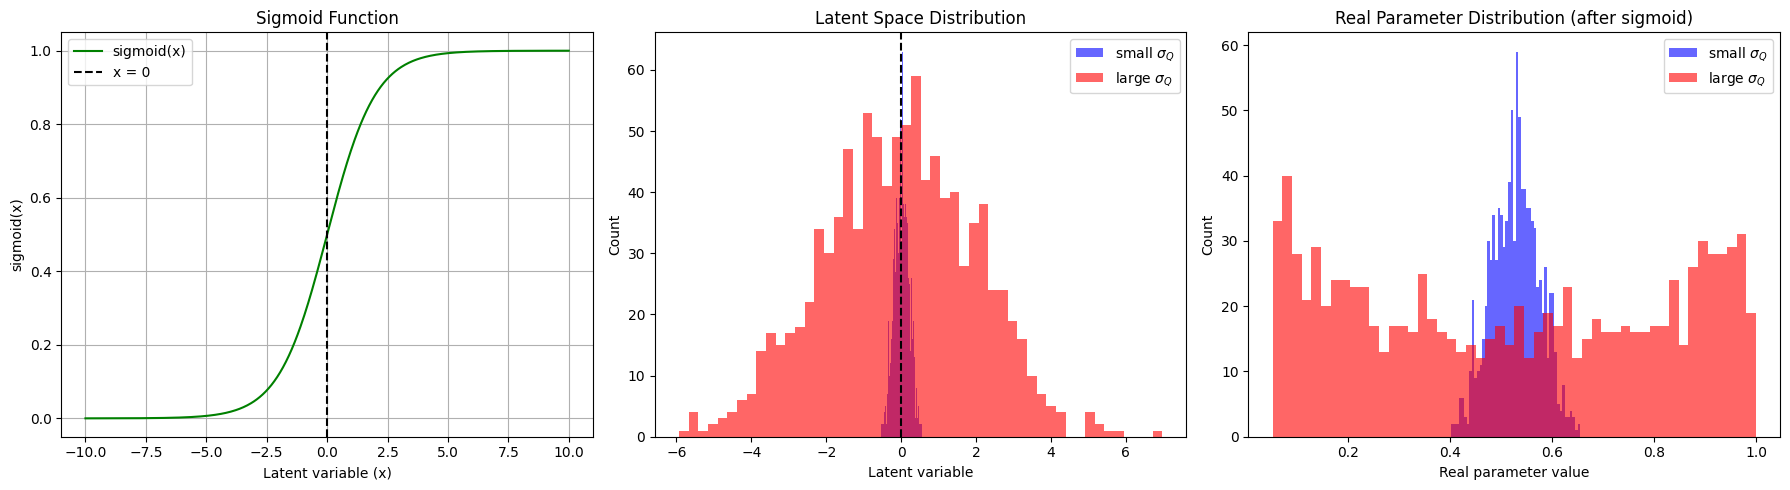

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid and its real-space transform
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def latent_to_real(latent, lb=0.05, ub=1.0):
    return lb + (ub - lb) * sigmoid(latent)

# Settings
latent_mean = 0
ensemble_size = 1000
sig_q_small = 0.2
sig_q_large = 2.0

# Sample latent parameters
latent_small = np.random.normal(latent_mean, sig_q_small, ensemble_size)
latent_large = np.random.normal(latent_mean, sig_q_large, ensemble_size)

# Transform to real parameter space
real_small = latent_to_real(latent_small)
real_large = latent_to_real(latent_large)

# Prepare sigmoid function curve
x_vals = np.linspace(-10, 10, 500)
sigmoid_vals = sigmoid(x_vals)

# Plot all 3 panels
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: sigmoid function ---
axs[0].plot(x_vals, sigmoid_vals, color='green', label='sigmoid(x)')
axs[0].axvline(0, color='black', linestyle='--', label='x = 0')
axs[0].set_title("Sigmoid Function")
axs[0].set_xlabel("Latent variable (x)")
axs[0].set_ylabel("sigmoid(x)")
axs[0].grid(True)
axs[0].legend()

# --- Panel 2: latent space distributions ---
axs[1].hist(latent_small, bins=50, alpha=0.6, label='small $\sigma_Q$', color='blue')
axs[1].hist(latent_large, bins=50, alpha=0.6, label='large $\sigma_Q$', color='red')
axs[1].axvline(0, color='black', linestyle='--')
axs[1].set_title("Latent Space Distribution")
axs[1].set_xlabel("Latent variable")
axs[1].set_ylabel("Count")
axs[1].legend()

# --- Panel 3: real param distributions after sigmoid ---
axs[2].hist(real_small, bins=50, alpha=0.6, label='small $\sigma_Q$', color='blue')
axs[2].hist(real_large, bins=50, alpha=0.6, label='large $\sigma_Q$', color='red')
axs[2].set_title("Real Parameter Distribution (after sigmoid)")
axs[2].set_xlabel("Real parameter value")
axs[2].set_ylabel("Count")
axs[2].legend()

plt.tight_layout()
plt.show()


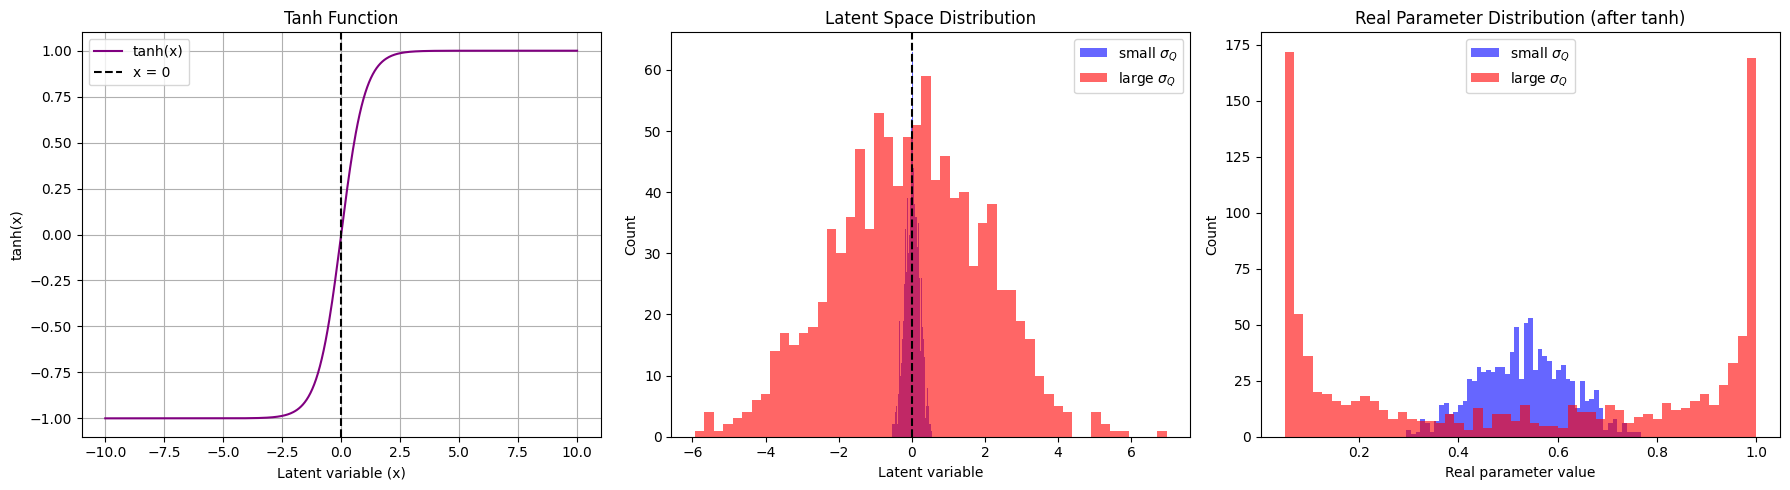

In [13]:
# Define tanh-based mapping function and its real-space transform
def tanh(x):
    return np.tanh(x)

def latent_to_real_tanh(latent, lb=0.05, ub=1.0):
    # tanh(x) is in (-1, 1), rescale to (0, 1), then to (lb, ub)
    scaled = (tanh(latent) + 1) / 2
    return lb + (ub - lb) * scaled

# Transform latent samples using tanh
real_small_tanh = latent_to_real_tanh(latent_small)
real_large_tanh = latent_to_real_tanh(latent_large)

# Prepare tanh function curve
tanh_vals = tanh(x_vals)

# Plot all 3 panels (tanh version)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: tanh function ---
axs[0].plot(x_vals, tanh_vals, color='purple', label='tanh(x)')
axs[0].axvline(0, color='black', linestyle='--', label='x = 0')
axs[0].set_title("Tanh Function")
axs[0].set_xlabel("Latent variable (x)")
axs[0].set_ylabel("tanh(x)")
axs[0].grid(True)
axs[0].legend()

# --- Panel 2: latent space distributions (same as before) ---
axs[1].hist(latent_small, bins=50, alpha=0.6, label='small $\sigma_Q$', color='blue')
axs[1].hist(latent_large, bins=50, alpha=0.6, label='large $\sigma_Q$', color='red')
axs[1].axvline(0, color='black', linestyle='--')
axs[1].set_title("Latent Space Distribution")
axs[1].set_xlabel("Latent variable")
axs[1].set_ylabel("Count")
axs[1].legend()

# --- Panel 3: real param distributions after tanh ---
axs[2].hist(real_small_tanh, bins=50, alpha=0.6, label='small $\sigma_Q$', color='blue')
axs[2].hist(real_large_tanh, bins=50, alpha=0.6, label='large $\sigma_Q$', color='red')
axs[2].set_title("Real Parameter Distribution (after tanh)")
axs[2].set_xlabel("Real parameter value")
axs[2].set_ylabel("Count")
axs[2].legend()

plt.tight_layout()
plt.show()
